# From string diagrams to sudoku solvers: syntax, semantics and functors in `discopy.neural`

This notebook is a slow, pedagogical companion to
[`neural-sudoku.ipynb`](neural-sudoku.ipynb).  It builds the same machinery,
but makes the category theory explicit at every step.  The picture is a
strict separation of *syntax* and *semantics*, connected by a functor:

```text
        SYNTAX                    functor  F : S -> N                SEMANTICS
┌──────────────────────┐                              ┌──────────────────────────────┐
│  skeletons   S       │     ob : role ↦ Dim(width)   │  neural networks   N         │
│                      │     ar : box  ↦ Network      │  (discopy.neural)            │
│  objects:  the roles │  ──────────────────────────► │  objects:  dimensions Dim(w) │
│  a port can play     │                              │  morphisms: torch modules    │
│  morphisms: empty    │                              │  wrapped as Networks         │
│  shells + wiring     │                              │                              │
└──────────────────────┘                              └──────────────────────────────┘
   pure combinatorics,                                   executed by message passing
   no torch imported                                     (the GoI execution formula)
```

* **Section 1** builds the *semantic* category $N$ = `discopy.neural`: its objects,
  its morphisms, its compact closed structure, and how a diagram *executes* by
  synchronous message passing.
* **Section 2** builds the *syntactic* category $S$ of **skeletons**: wiring
  diagrams whose types are the *roles* ports play (`peer`, `state`, `clue`)
  and whose boxes carry no modules at all.
* **Section 3** builds the **functor** $F : S \to N$ that fills each role
  with a width and each shell with a `torch.nn.Module` — and shows why this
  makes swapping modules plug-and-play.
* **Section 4** applies the formalism to a 4×4 sudoku grid: **one skeleton,
  two functors** — a feedforward interpretation and a recurrent (GRU) one.
* **Sections 5–6** scale the *syntax* to 6×6 — where the interpretations
  genuinely come apart — add a third, **sparser topology** (the factor graph
  of row/column/block constraints), train all three side by side, and
  compare their training curves and running times on two plots.
* **Section 7** points at the 9×9 study in `docs/neural`, which is exactly
  this notebook scaled up once more.

Everything is deliberately tiny (widths 8 and 16, grids of 16 and 36 cells,
a few hundred puzzles): the notebook runs end to end on a laptop CPU, and
uses a GPU automatically when one is detected.

In [1]:
import time
import random

import torch
import matplotlib.pyplot as plt

from discopy import frobenius
from discopy.frobenius import Box, Ty
from discopy.neural import CMap, Cap, Cup, Diagram, Dim, Functor, Id, Network

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cpu":
    # at these tiny widths, handing work to a thread pool costs more than
    # the arithmetic itself: one thread is severalfold faster
    torch.set_num_threads(1)
print(f"running on {device}")
torch.manual_seed(42)


def mlp(width):
    """The simplest module of the right shape: R^width -> R^width."""
    return torch.nn.Sequential(
        torch.nn.Linear(width, 2 * width), torch.nn.Tanh(),
        torch.nn.Linear(2 * width, width))

running on cuda


## 1. The semantic category $N$: bidirectional neural networks

`discopy.neural` is a **compact closed category**.  Spelled out:

**Objects** are `Dim(a, b, ...)` — tuples of positive integers.

* The tensor `@` is concatenation of tuples.  Networks compose with the
  *cartesian product* of vector spaces, so the tensor of dimensions is their
  **sum**: `Dim(2) @ Dim(3)` carries $\mathbb{R}^2 \times \mathbb{R}^3
  \cong \mathbb{R}^5$.
* The monoidal unit is `Dim(0)`, the zero-dimensional space: `Dim(0) == Dim()`
  and tensoring with it does nothing.  Remember this object — it is the whole
  trick behind Section 3's *erasure*.
* Every object is **self-dual**: the left and right duals both just reverse
  the tuple, and an atomic `Dim(w)` is its own dual.

**Morphisms** are `Network(name, dom, cod, module)`: a box
$f : \mathtt{Dim}(a) \to \mathtt{Dim}(b)$ carrying **one** torch module
$m : \mathbb{R}^{a+b} \to \mathbb{R}^{a+b}$.  The convention is
*bidirectional*: the module reads an incoming message on **every** port —
domain and codomain alike — and emits an outgoing message on every port.  So
a `Network` is *not* a function from its domain to its codomain; it is a
local **message transformer**, and the global function is produced by
*executing* the diagram (Section 1.1).

**Structure.**  `>>` composes, `@` tensors, and `Cup`, `Cap`, `Swap` are
**pure rerouting**: they carry no parameters, which is exactly what
self-duality buys us.  `Cap(y, y)` creates a pair of wires out of nothing and
`Cup(y, y)` merges two wires — together they bend wires around and build
feedback loops.

In [2]:
x, y = Dim(2), Dim(3)

# the object algebra: tensor = concatenation ~ addition, unit = Dim(0)
assert Dim(0) == Dim() and Dim(0) @ x == x == x @ Dim(0)
assert x @ y == Dim(2, 3) and (x @ y) @ x == Dim(2, 3, 2)
assert Dim(2, 3).l == Dim(2, 3).r == Dim(3, 2)      # self-dual: just reversed
print(f"x @ y = {x @ y},  its dual: {(x @ y).l},  the unit: {Dim(0)!r}")

x @ y = Dim(2, 3),  its dual: Dim(3, 2),  the unit: Dim(0)


f >> g : Dim(2) -> Dim(2)
feedback : Dim(2) -> Dim(2)


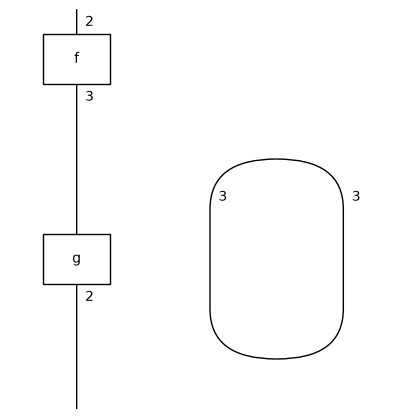

In [3]:
# two morphisms of N; each carries one module of width dom + cod
f = Network('f', x, y, module=mlp(2 + 3))    # f : Dim(2) -> Dim(3), on R^5
g = Network('g', y, x, module=mlp(3 + 2))    # g : Dim(3) -> Dim(2), on R^5

h = f >> g                                   # composition: types compose
print(f"f >> g : {h.dom} -> {h.cod}")

# compact closure: bend g's wires around with a cap and a cup,
# turning the composite into a feedback loop on f
feedback = f @ Cap(y, y) >> g @ Id(y @ y) >> Id(x) @ Cup(y, y)
print(f"feedback : {feedback.dom} -> {feedback.cod}")
feedback.draw(figsize=(4, 4))

The compact closed axioms hold *on the nose* once we compare diagrams by
their wiring rather than by their layer-by-layer presentation: the **snake
equations** say that bending a wire right and then left (or vice versa) is
the same as not bending it at all.

In [4]:
Diagram.use_hypergraph_equality = True
assert Id(x).transpose() == Id(x) == Id(x).transpose(left=True)   # the snakes
Diagram.use_hypergraph_equality = False

### 1.1 Execution: message passing is the geometry of interaction

A diagram is *evaluated* by turning it into a **combinatorial map** with
`.to_map()`.  Two things happen:

* cups, caps and swaps **dissolve**: all that remains of them is wiring — a
  fixpoint-free involution $\sigma$ on the set of ports, pairing each port
  with the one at the other end of its wire;
* only the `Network` boxes survive.

Calling the map runs **synchronous message passing**.  One round:

1. every box reads the incoming message on each of its ports, feeds their
   concatenation to its module, and splits the output back into one outgoing
   message per port;
2. $\sigma$ routes every outgoing message to the port at the other end of
   its wire;
3. boundary inputs are (re-)delivered along their wires.

That is the **execution formula** of the geometry of interaction,

$$m \;\longmapsto\; \sigma \Big(\bigoplus_i f_i\Big)(m),$$

see Abramsky's *Retracing some paths in process algebra* and
`discopy.interaction` for the Int-construction of Joyal, Street & Verity.
Rounds **compose**: running $a+b$ rounds equals running $a$ rounds and
resuming for $b$ more — a law the 9×9 study's model C exploits to cut long
runs into resumable segments.

For a map with no boxes, execution is pure rerouting:

In [5]:
snake = Id(Dim(2)).transpose().to_map()
assert snake.boxes == ()                       # the cup and cap dissolved

point = torch.tensor([[0.1, 0.2]])
assert (snake(point) == point).all()           # rerouted, unchanged

swap = Diagram.swap(Dim(2), Dim(3)).to_map()
swap(torch.tensor([[1., 2., 3., 4., 5.]]))     # blocks exchanged

tensor([[3., 4., 5., 1., 2.]])

In [6]:
# the execution formula by hand, on the smallest possible map: one box.
# f : Dim(2) -> Dim(3) has four ports: boundary input, box domain port,
# box codomain port, boundary output.
fm = f.to_map()
print(f"port widths: {fm.port_widths}")

# one round: the box reads [input, 0] (nothing has arrived on its codomain
# port yet), its module runs, and sigma routes the last 3 coordinates of the
# output to the boundary.
xin = torch.rand(1, 2)
with torch.no_grad():
    by_map = fm(xin, n_rounds=1)
    by_hand = f.module(torch.cat([xin, torch.zeros(1, 3)], -1))[:, 2:]
assert torch.allclose(by_map, by_hand)
print("one round of the map == route the module output along sigma  ✓")

port widths: (2, 2, 3, 3)
one round of the map == route the module output along sigma  ✓


## 2. The syntactic category $S$: skeletons

An architecture has two independent ingredients: **who talks to whom** (a
graph) and **what they say** (widths and modules).  The syntactic category
pins down the first without mentioning the second — it does not even import
torch (`import discopy` never does).

**Objects** are `frobenius.Ty` types over a handful of atoms we call
**roles**: `Ty("peer")`, `Ty("state")`, `Ty("clue")`.  A type is a finite
list of roles — the *port signature* of a box.  Frobenius types are
self-dual, which is what lets a wire connect two *codomain* ports; closed
maps need that constantly.

**Morphisms** are plain `frobenius.Box(name, dom, cod)`: **no module
inside**, an empty shell whose only content is its name and its port
signature.  From these, `CMap.from_wiring(boxes, wires)` builds a **closed
combinatorial map**: each wire is a pair of `(box, port)` endpoints, and
together the wires form a fixpoint-free involution $\sigma$ on the ports.

Two remarks about *closed* maps:

* they have no boundary — no global input or output.  Inputs will enter as
  *initial messages* and outputs will be read off the *per-box emissions*;
* a wire between two ports of the **same box** is a **trace**, i.e. a
  feedback loop: whatever the box emits there comes back to *itself* next
  round.  We use two idioms — a `state` loop (private memory that survives a
  round) and a `clue` loop (a parking slot where a problem input is written).

Here is a tiny skeleton: two cells talking over one `peer` wire, each with a
`state` loop.

cell : Ty() -> peer @ state @ state
boxes: ['cell', 'cell'],  ports: 6,  sigma: (1, 0, 5, 4, 3, 2)


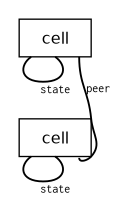

In [7]:
# the roles: atomic objects of S
PEER, STATE, CLUE = Ty("peer"), Ty("state"), Ty("clue")

# one generating morphism: a cell shell with one peer port and a state loop
cell = Box("cell", Ty(), PEER @ STATE ** 2)
print(f"cell : {cell.dom} -> {cell.cod}")

# a closed map: two cells, one peer wire, two state loops
tiny = frobenius.CMap.from_wiring(
    boxes=(cell, cell),
    wires=[((0, 0), (1, 0)),      # cell 0's peer port <-> cell 1's peer port
           ((0, 1), (0, 2)),      # cell 0's state loop  (a trace)
           ((1, 1), (1, 2))])     # cell 1's state loop  (a trace)

print(f"boxes: {[box.name for box in tiny.boxes]},  ports: {tiny.n_ports},  "
      f"sigma: {tiny.edges}")
assert all(tiny.edges[tiny.edges[i]] == i != tiny.edges[i]
           for i in range(tiny.n_ports))     # sigma is a fixpoint-free involution
tiny.draw()

In [8]:
# three helpers to read a closed skeleton back, port by port
# (inlined from docs/neural/experiments/skeleton.py)

def logical_ports(cmap, index):
    """Global port indices of a box in logical order: domain then codomain,
    undoing the clockwise storage order which keeps the codomain reversed."""
    start = len(cmap.dom)
    for box in cmap.boxes[:index]:
        start += len(box.dom) + len(box.cod)
    box = cmap.boxes[index]
    arity = len(box.dom)
    ports = tuple(range(start, start + arity + len(box.cod)))
    return ports[:arity] + tuple(reversed(ports[arity:]))


def wires_of(cmap):
    """The wires of a closed map as pairs of (box, port) pairs —
    the inverse of CMap.from_wiring."""
    to_logical = {port: (index, position)
                  for index in range(len(cmap.boxes))
                  for position, port in enumerate(logical_ports(cmap, index))}
    return tuple((to_logical[i], to_logical[j])
                 for i, j in enumerate(cmap.edges) if i < j)


def roles_of(cmap, index):
    """The role of each logical port of a box: its domain then its codomain."""
    box = cmap.boxes[index]
    return tuple(box.dom) + tuple(box.cod)


print(f"wires, read back:  {wires_of(tiny)}")
print(f"roles of a cell:   {[str(role) for role in roles_of(tiny, 0)]}")

wires, read back:  (((0, 2), (0, 1)), ((0, 0), (1, 0)), ((1, 2), (1, 1)))
roles of a cell:   ['peer', 'state', 'state']


## 3. The functor $F : S \to N$

A `neural.Functor` is exactly the data of an *interpretation* of the syntax:

* **on objects** — a mapping `ob` sending each atomic role to the `Dim` it
  will carry, extended monoidally: $F(u \otimes v) = F(u) \otimes F(v)$;
* **on morphisms** — a mapping `ar` sending each abstract box to a `Network`
  *of the image type*, $F(\mathtt{cell}) : F(\mathrm{dom}) \to
  F(\mathrm{cod})$, carrying the actual torch module.

`interpret` below applies $F$ to a whole closed map, port by port: each box
becomes its image `Network`, each wire becomes a wire between the image
ports.  This is the boundary between syntax and semantics: **the skeleton
fixes the combinatorics, the functor fixes the widths and the modules.**

One feature deserves emphasis.  `Dim(0)` is the monoidal unit, so sending a
role to `Dim(0)` means *"this role carries nothing"* — and a port carrying
nothing **is not there at all**: `interpret` erases it, together with any
wire whose two ends are both erased.  One skeleton can therefore serve
several architectures: keep the state loop or erase it, keep an answer loop
or erase it, all through the object map alone.  (A wire may only be erased
*whole*: erasing exactly one end is a type error, and `interpret` raises.)

In [9]:
# (inlined, lightly simplified, from docs/neural/experiments/maps.py)

def make_functor(ob, modules, abstract):
    """The neural functor with object map `ob`, sending each abstract box of
    `abstract` to a Network of the image type around modules[box.name].
    Note that one shared module means one shared box: weights are tied."""
    types = Functor(ob=ob, dom=frobenius.Diagram)          # F on objects only
    networks = {box: Network(box.name, types(box.dom), types(box.cod),
                             module=modules[box.name])
                for box in dict.fromkeys(abstract.boxes)}
    return Functor(ob=ob, ar=networks, dom=frobenius.Diagram)


def interpret(functor, abstract):
    """Apply a neural functor to a closed skeleton, port by port."""
    boxes = tuple(functor(box) for box in abstract.boxes)
    for box, image in zip(abstract.boxes, boxes):
        assert isinstance(image, Network)
        assert (image.dom, image.cod) == (functor(box.dom), functor(box.cod))

    # where each abstract port lands, and whether it was erased by Dim(0)
    erased, position = {}, {}
    for index in range(len(abstract.boxes)):
        cursor = 0
        for pos, role in enumerate(roles_of(abstract, index)):
            width = functor(role)
            assert len(width) <= 1, f"{role} maps to the non-atomic {width}"
            erased[index, pos] = not len(width)      # Dim(0) has length 0
            position[index, pos] = cursor
            cursor += len(width)

    # each wire becomes a wire between image ports, or vanishes whole
    wires = []
    for one, other in wires_of(abstract):
        if erased[one] and erased[other]:
            continue
        assert not (erased[one] or erased[other]), \
            f"the wire {one} -- {other} is only erased at one end"
        wires.append(((one[0], position[one]), (other[0], position[other])))
    return CMap.from_wiring(boxes, wires)

In [10]:
# --- functor 1: a "wide" interpretation ------------------------------------
ob_wide = {PEER: Dim(2), STATE: Dim(3)}
F_wide = make_functor(ob_wide, {"cell": mlp(2 + 3 + 3)}, tiny)

print("F_wide on objects:")
for role, dim in ob_wide.items():
    print(f"    F({role}) = {dim}")
image = F_wide(cell)
print(f"F_wide on morphisms:\n    F(cell) = {image!r},")
print(f"        carrying one {type(image.module).__name__} on "
      f"R^{sum(image.cod.inside)}")
assert F_wide(PEER @ STATE ** 2) == F_wide(PEER) @ F_wide(STATE) ** 2

wide = interpret(F_wide, tiny)
out = wide(n_rounds=3)         # a closed map returns the per-box emissions
print(f"image map: port widths {wide.port_widths};  3 rounds of message "
      f"passing -> {len(out)} tensors of shape {tuple(out[0].shape)}")

# --- functor 2: the same skeleton, with the state loops erased -------------
F_erased = make_functor({PEER: Dim(2), STATE: Dim(0)}, {"cell": mlp(2)}, tiny)
erased = interpret(F_erased, tiny)
print(f"\nF(STATE) = Dim(0):  port widths {erased.port_widths}  "
      "(the state loops vanished)")

# --- functor 3: same widths as F_wide, a different module — plug and play --
F_swapped = make_functor(ob_wide, {"cell": torch.nn.Linear(8, 8)}, tiny)
swapped = interpret(F_swapped, tiny)
assert swapped.port_widths == wide.port_widths
print(f"\nsame skeleton, same widths, module swapped: "
      f"{type(swapped.boxes[0].module).__name__} instead of "
      f"{type(wide.boxes[0].module).__name__}")

F_wide on objects:
    F(peer) = Dim(2)
    F(state) = Dim(3)
F_wide on morphisms:
    F(cell) = neural.Network('cell', dom=Dim(0), cod=Dim(2, 3, 3)),
        carrying one Sequential on R^8
image map: port widths (3, 3, 2, 3, 3, 2);  3 rounds of message passing -> 2 tensors of shape (1, 8)

F(STATE) = Dim(0):  port widths (2, 2)  (the state loops vanished)

same skeleton, same widths, module swapped: Linear instead of Sequential


## 4. One skeleton, two functors: 4×4 sudoku

In a sudoku grid of block shape $h \times w$, the grid has $hw \cdot hw$
cells, each holding a digit $1 \ldots hw$, and no two **peers** — cells
sharing a row, a column or an $h \times w$ block — may hold the same digit.
The block shape is the *only* parameter:

| block | grid | cells | peers per cell | peer wires |
|---|---|---|---|---|
| (2, 2) | 4×4 | 16 | 7 | 56 |
| (2, 3) | 6×6 | 36 | 12 | 216 |
| (3, 3) | 9×9 | 81 | 20 | 810 |

The skeleton gives every cell the **full** signature
$\mathtt{peer}^P \otimes \mathtt{state}^2 \otimes \mathtt{clue}^2$:
$P$ peer ports, a state loop and a clue loop.  All the boxes are the *same*
`cell` shell, and the wiring pairs each cell with its peers plus the two
self-loops.  Note that the whole sudoku family — square or rectangular
blocks alike — lives in the **syntax**: nothing below mentions widths or
modules.

Both solvers of this notebook interpret **one skeleton per grid size**:

* the **feedforward functor** sends `STATE ↦ Dim(0)` and `CLUE ↦ Dim(0)`:
  both loops are erased, cells are memoryless MLPs, and the clues will have
  to be re-injected on the peer ports at every round;
* the **recurrent functor** sends `STATE ↦ Dim(16)` and `CLUE ↦ Dim(8)`: the
  state loop becomes the hidden state of a GRU (a trace!), and the clue loop
  becomes the slot where the puzzle is written.

This is the same move as models A and C of the 9×9 study
(`docs/neural/experiments/maps.py`): they share one factor-graph skeleton
and differ only on the `answer` role — `Dim(0)` for A, `Dim(48)` for C.

In [11]:
def sudoku_peers(block=(2, 2)):
    """Peers of each cell: same row, same column or same h x w block."""
    height, width = block
    size = height * width

    def same_unit(cell, other):
        (r, c), (rr, cc) = divmod(cell, size), divmod(other, size)
        return r == rr or c == cc or \
            (r // height, c // width) == (rr // height, cc // width)

    return tuple(tuple(sorted(
        other for other in range(size * size)
        if other != cell and same_unit(cell, other)))
        for cell in range(size * size))


def sudoku_skeleton(block=(2, 2)):
    """One shared cell shell per cell, with the full signature
    PEER^P @ STATE^2 @ CLUE^2; a wire between each pair of peers, plus a
    state loop and a clue loop on every cell.  Pure syntax: no widths,
    no modules, no torch."""
    peers = sudoku_peers(block)
    n_cells, P = len(peers), len(peers[0])
    shell = Box("cell", Ty(), PEER ** P @ STATE ** 2 @ CLUE ** 2)
    wires = [((c, peers[c].index(o)), (o, peers[o].index(c)))
             for c in range(n_cells) for o in peers[c] if c < o]
    for c in range(n_cells):
        wires.append(((c, P), (c, P + 1)))          # state loop
        wires.append(((c, P + 2), (c, P + 3)))      # clue loop
    return frobenius.CMap.from_wiring(n_cells * (shell, ), wires)


skeleton4 = sudoku_skeleton(block=(2, 2))
P4 = len(sudoku_peers(block=(2, 2))[0])
print(f"peers of cell 0 on 4x4: {sudoku_peers(block=(2, 2))[0]}")
print(f"4x4 skeleton: {len(skeleton4.boxes)} cells, {skeleton4.n_ports} "
      f"ports, {skeleton4.n_ports // 2} wires — "
      "and not a torch tensor in sight")

peers of cell 0 on 4x4: (1, 2, 3, 4, 5, 8, 12)
4x4 skeleton: 16 cells, 176 ports, 88 wires — and not a torch tensor in sight


In [12]:
def gru_cell(dim, state_dim, hidden_dim=None):
    """The module behind the recurrent functor.

    It reads its ports in the cell's logical order ``[m_1 .. m_P | h, h' |
    c, c']``: P peer messages, the state loop pair, the clue loop pair.
    Each round it encodes every peer message against its own state,
    mean-pools the encodings, runs a GRU update from the pool and the clue,
    then broadcasts a fresh belief to its peers and emits the new state on
    both state ports.  On the clue ports it emits zeros, so the injected
    clue arrives unchanged every round.

    The number of peers is read off the input width, so the same weights
    run on any grid size."""
    hidden_dim = hidden_dim or 2 * state_dim

    class EquivariantGRUCell(torch.nn.Module):
        def __init__(self):
            super().__init__()
            self.dim, self.state_dim = dim, state_dim
            self.encode = torch.nn.Sequential(
                torch.nn.Linear(state_dim + dim, hidden_dim),
                torch.nn.ReLU(), torch.nn.Linear(hidden_dim, hidden_dim))
            self.update = torch.nn.GRUCell(hidden_dim + dim, state_dim)
            self.norm = torch.nn.LayerNorm(state_dim)
            self.emit = torch.nn.Linear(state_dim, dim)

        def forward(self, x):
            d, s = self.dim, self.state_dim
            P = (x.shape[-1] - 2 * s - 2 * d) // d
            peers = x[:, :P * d].reshape(-1, P, d)
            state = x[:, P * d:P * d + s]
            clue = x[:, P * d + 2 * s:P * d + 2 * s + d]
            pooled = self.encode(torch.cat([
                state.unsqueeze(1).expand(-1, P, -1), peers], -1)).mean(1)
            state = self.norm(self.update(
                torch.cat([pooled, clue], -1), state))
            return torch.cat([
                self.emit(state).unsqueeze(1).expand(-1, P, -1)
                    .reshape(-1, P * d),
                state, state,
                torch.zeros_like(clue), torch.zeros_like(clue)], -1)

    return EquivariantGRUCell()

In [13]:
dim, state_dim = 8, 16

# the two functors, differing ONLY in where they send the roles
F_feedforward4 = make_functor(
    ob={PEER: Dim(dim), STATE: Dim(0), CLUE: Dim(0)},
    modules={"cell": mlp(P4 * dim)}, abstract=skeleton4)

rec_module = gru_cell(dim, state_dim)      # kept: reused on 6x6 and 9x9 below
F_recurrent4 = make_functor(
    ob={PEER: Dim(dim), STATE: Dim(state_dim), CLUE: Dim(dim)},
    modules={"cell": rec_module}, abstract=skeleton4)

grid4_ff = interpret(F_feedforward4, skeleton4)
grid4_rec = interpret(F_recurrent4, skeleton4)

for name, grid in [("feedforward", grid4_ff), ("recurrent", grid4_rec)]:
    widths = grid.port_widths
    n_parameters = sum(p.numel() for p in grid.parameters())
    print(f"{name:12s} image: {len(grid.boxes)} cells x "
          f"{len(widths) // len(grid.boxes)} ports, {len(widths) // 2} wires, "
          f"{n_parameters} shared parameters")

assert grid4_ff.port_widths == 16 * 7 * (dim, )      # the loops are erased
assert len(grid4_rec.port_widths) == 16 * 11         # 7 peers + 2 + 2 loops

feedforward  image: 16 cells x 7 ports, 56 wires, 12712 shared parameters
recurrent    image: 16 cells x 11 ports, 88 wires, 4808 shared parameters


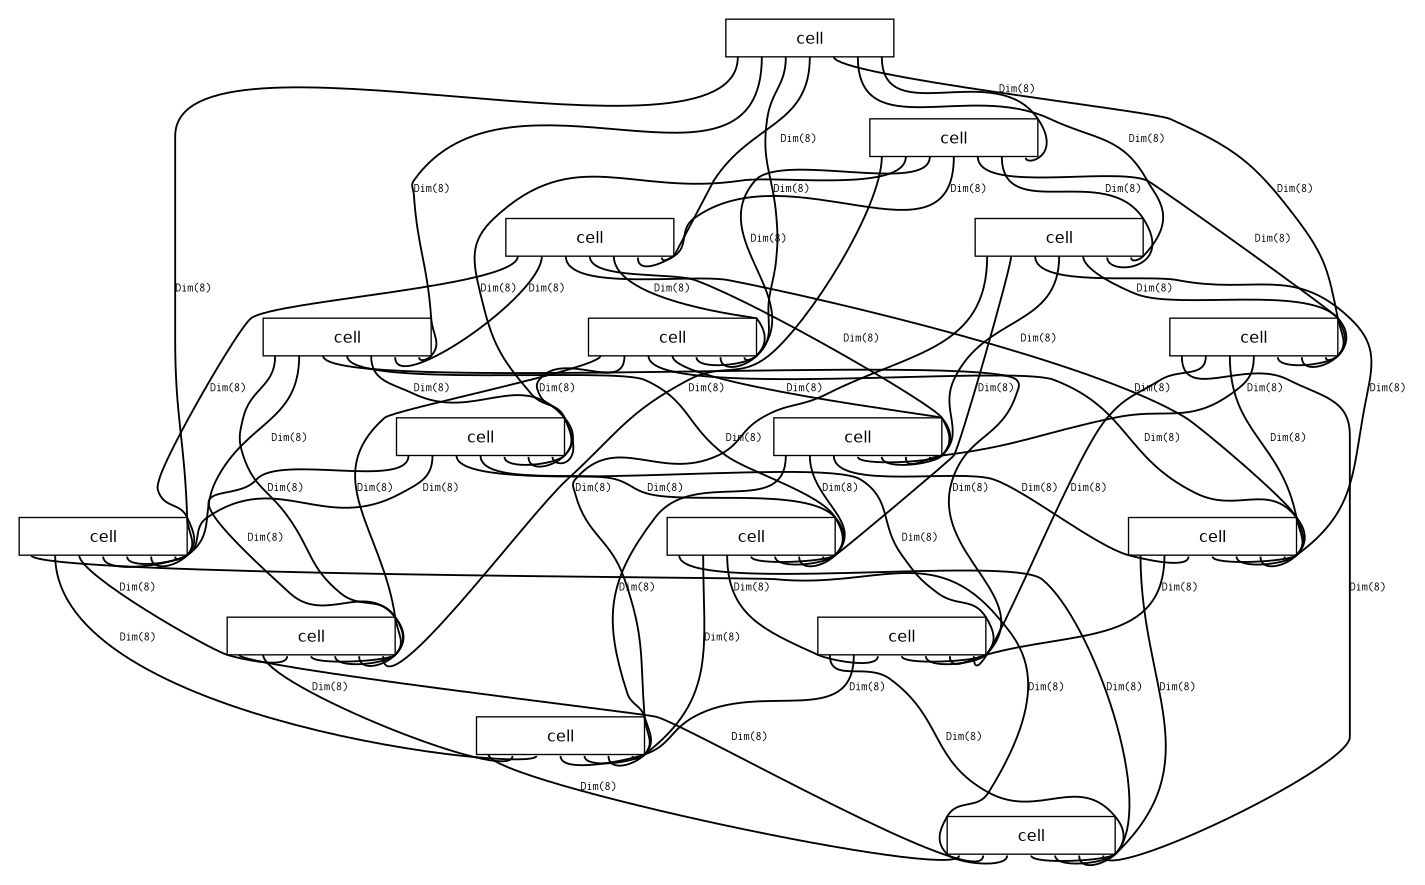

In [14]:
grid4_ff.draw()   # the interpreted 4x4 grid: highly non-planar, one shared box

## 5. Scaling the syntax: 6×6, where the two functors come apart

We first ran the comparison on 4×4 and it was a draw: with eight givens both
interpretations exceed 90% valid boards in seconds — sixteen cells over four
digits is too easy to tell a memoryless cell from a stateful one.

So we scale **the syntax, not the formalism**: block shape `(2, 3)` gives
the 6×6 grid — 36 cells, 12 peers each, digits 1–6, rectangular blocks —
and the skeleton builder above absorbs it without a new line of code.  On
the semantic side the asymmetry between the two functors becomes visible:

* the **recurrent module transfers unchanged** — it reads its number of
  peers off the input width, so the very same weights interpret the 4×4,
  6×6 and 9×9 skeletons;
* the **memoryless MLP does not** — it is a fixed-width module wired to a
  fixed peer count, so the feedforward functor needs a fresh module of width
  $12 \cdot 8 = 96$.

The choice of module *is* the choice of what the functor can range over.

In [15]:
skeleton6 = sudoku_skeleton(block=(2, 3))
P6 = len(sudoku_peers(block=(2, 3))[0])
print(f"6x6 skeleton: {len(skeleton6.boxes)} cells, {P6} peers per cell, "
      f"{skeleton6.n_ports // 2} wires")

F_feedforward6 = make_functor(
    ob={PEER: Dim(dim), STATE: Dim(0), CLUE: Dim(0)},
    modules={"cell": mlp(P6 * dim)}, abstract=skeleton6)   # a fresh module
F_recurrent6 = make_functor(
    ob={PEER: Dim(dim), STATE: Dim(state_dim), CLUE: Dim(dim)},
    modules={"cell": rec_module}, abstract=skeleton6)      # the same module

grid6_ff = interpret(F_feedforward6, skeleton6)
grid6_rec = interpret(F_recurrent6, skeleton6)
assert set(id(p) for p in grid6_rec.parameters()) \
    == set(id(p) for p in grid4_rec.parameters())   # literally the same weights

# the same module even interprets the 9x9 skeleton, 20 peers per cell:
grid9_rec = interpret(make_functor(
    ob={PEER: Dim(dim), STATE: Dim(state_dim), CLUE: Dim(dim)},
    modules={"cell": rec_module}, abstract=sudoku_skeleton(block=(3, 3))),
    sudoku_skeleton(block=(3, 3)))
print(f"9x9 image: {len(grid9_rec.boxes)} cells, {grid9_rec.n_ports // 2} "
      "wires, same weights as the 4x4 and 6x6 maps")

# and the two spellings of execution agree: the vectorized flat-tensor pass
# and the readable one-call-per-box reference
init = torch.rand(4, sum(grid6_rec.port_widths))
with torch.no_grad():
    reference = grid6_rec.forward_reference(init=init, n_rounds=3)
    vectorized = grid6_rec.forward(init=init, n_rounds=3)
assert all(torch.allclose(a, b, atol=1e-5)
           for a, b in zip(reference, vectorized))
print("forward == forward_reference  ✓")

6x6 skeleton: 36 cells, 12 peers per cell, 288 wires


9x9 image: 81 cells, 972 wires, same weights as the 4x4 and 6x6 maps


forward == forward_reference  ✓


### 5.1 A third topology: the factor graph

The clique is not the only way to wire the constraints — and this is the
point of keeping the syntax separate: **for one problem, several topologies
can be tried**, each one small skeleton away.

A sudoku constraint says *"these six cells hold distinct digits"*.  The
clique encodes it as $\binom{6}{2} = 15$ pairwise wires; the **factor
graph** encodes it as a single *relation box*: one **unit** shell per row,
column and block with one `message` port per member, and a cell shell with
just **three** `message` ports — one to its row, one to its column, one to
its block — plus the same state and clue loops.  For 6×6 that is $36 + 18 =
54$ boxes and $108 + 72 = 180$ wires against the clique's 36 boxes and 288
wires: a sparser map, with one more box shape.  It is exactly the skeleton
of model A in the 9×9 study (`experiments/skeleton.py: factor_graph`).

On the semantic side the functor needs one new module — a **Deep-Sets
relation** for the unit box, pooling its members into an order-invariant
summary and answering each member — while the cell reuses the very same
`gru_cell` *class*: it reads its port count off the width, so it now reads
3 unit summaries instead of 12 raw peer messages, unchanged.

The price of sparsity is **distance**: a belief travels cell → unit → cell,
so one cell-to-cell hop costs *two* rounds here and one in the clique.  We
give this map 24 rounds (12 hops) against the clique's 16.

In [16]:
MESSAGE = Ty("message")     # a fourth role: a cell-to-unit wire


def sudoku_units(block=(2, 3)):
    """The row, column and block unit index of each cell."""
    height, width = block
    size = height * width
    units = []
    for cell_index in range(size * size):
        row, column = divmod(cell_index, size)
        block_index = (row // height) * (size // width) + (column // width)
        units.append((row, size + column, 2 * size + block_index))
    return tuple(units)


def factor_skeleton(block=(2, 3)):
    """The bipartite factor graph: one cell shell with three MESSAGE ports
    and the two loops, one unit shell per row/column/block with one MESSAGE
    port per member, and a wire from each cell to each of its three units.
    Pure syntax again — the same move as sudoku_skeleton, different wiring."""
    height, width = block
    size = height * width
    n_cells = size * size
    units = sudoku_units(block)
    cell_shell = Box("cell", Ty(), MESSAGE ** 3 @ STATE ** 2 @ CLUE ** 2)
    unit_shell = Box("unit", Ty(), MESSAGE ** size)
    free = [0] * (3 * size)
    wires = []
    for index in range(n_cells):
        for position, unit_index in enumerate(units[index]):
            wires.append(
                ((index, position), (n_cells + unit_index, free[unit_index])))
            free[unit_index] += 1
        wires.append(((index, 3), (index, 4)))      # state loop
        wires.append(((index, 5), (index, 6)))      # clue loop
    assert all(slot == size for slot in free), "a unit box is not full"
    return frobenius.CMap.from_wiring(
        (cell_shell, ) * n_cells + (unit_shell, ) * (3 * size), wires)


class FactorBox(torch.nn.Module):
    """A permutation-equivariant Deep-Sets relation over one unit's
    members: pool an order-invariant summary of the unit (a sum), answer
    each member with that summary alongside its own message."""
    def __init__(self, dim, hidden):
        super().__init__()
        self.dim = dim
        self.phi = torch.nn.Sequential(
            torch.nn.Linear(dim, hidden), torch.nn.ReLU())
        self.rho = torch.nn.Sequential(
            torch.nn.Linear(dim + hidden, hidden), torch.nn.ReLU(),
            torch.nn.Linear(hidden, dim))

    def forward(self, x):
        members = x.shape[-1] // self.dim
        message = x.reshape(-1, members, self.dim)
        pooled = self.phi(message).sum(1, keepdim=True).expand(
            -1, members, -1)
        return self.rho(torch.cat([message, pooled], -1)).reshape(
            -1, members * self.dim)


skeleton6_factor = factor_skeleton(block=(2, 3))
F_factor6 = make_functor(
    ob={MESSAGE: Dim(dim), STATE: Dim(state_dim), CLUE: Dim(dim)},
    modules={"cell": gru_cell(dim, state_dim),   # same class, fresh weights
             "unit": FactorBox(dim, 32)},
    abstract=skeleton6_factor)
grid6_fac = interpret(F_factor6, skeleton6_factor)

print(f"{'topology':16s}{'boxes':>6s}{'wires':>7s}{'parameters':>12s}")
for name, grid in [("ff clique", grid6_ff), ("rec clique", grid6_rec),
                   ("rec factor", grid6_fac)]:
    print(f"{name:16s}{len(grid.boxes):6d}{grid.n_ports // 2:7d}"
          f"{sum(p.numel() for p in grid.parameters()):12d}")

topology         boxes  wires  parameters
ff clique           36    216       37152
rec clique          36    288        4808
rec factor          54    180        6672


### Clues in, digits out: the solvers

A closed map has no boundary, so a solver talks to it through the two
channels execution provides:

* **inputs** are *initial messages*: `forward(init=..., inject=True)` writes
  a tensor on chosen ports before the first round and re-adds it every round,
  so the clues act as a persistent source;
* **outputs** are the *per-box emissions*: what each cell said on its ports
  after the last round.

The three interpretations induce three data paths:

| | feedforward · clique | recurrent · clique | recurrent · factor |
|---|---|---|---|
| clues enter on | all 12 peer ports | the 2 clue-loop ports | the 2 clue-loop ports |
| memory | none (loops erased) | the state loop, a trace | the state loop, a trace |
| read out from | the 12 emitted messages | the state slice | the state slice |
| rounds | 8 | 16 | 24 (12 hops) |

Note that the two recurrent solvers are **one class**: the only numbers it
needs — how many message ports a cell has, where its state slice starts —
it takes as arguments, and the cell boxes come first in both wirings.

One more piece of the category at work: `grid.as_network()` wraps an
executed map **back into a `Network`** — a morphism of $N$ again, usable as
a box inside a larger diagram.  Here we keep its fresh module so that torch
registers the shared cell modules as submodules of the solver, which is what
lets `optimizer = Adam(solver.parameters())` see them.

In [17]:
class FeedforwardSolver(torch.nn.Module):
    """The feedforward interpretation, wrapped for training."""
    def __init__(self, grid, n_peers, size, dim=8, n_rounds=8):
        super().__init__()
        self.grid, self.n_rounds = grid, n_rounds
        self.cells = grid.as_network().module      # registers the shared module
        self.embedding = torch.nn.Embedding(size + 1, dim)  # 0 means blank
        self.readout = torch.nn.Linear(n_peers * dim, size)

    def forward(self, clues):
        embedded = self.embedding(clues)
        init = [None] * self.grid.n_ports
        for cell_index in range(clues.shape[1]):
            for port in self.grid.box_ports(cell_index):   # all P peer ports
                init[port] = embedded[:, cell_index, :]
        emitted = self.cells(init=init, n_rounds=self.n_rounds)
        return self.readout(torch.stack(emitted, dim=1))


class RecurrentSolver(torch.nn.Module):
    """A recurrent interpretation, wrapped for training.  Serves both the
    clique (n_message=12 peer ports) and the factor graph (n_message=3 unit
    ports): cell boxes come first in both wirings, so the clue ports and the
    state slice are found the same way."""
    def __init__(self, grid, n_message, size, dim=8, state_dim=16,
                 n_rounds=16):
        super().__init__()
        self.grid, self.n_rounds = grid, n_rounds
        self.n_message, self.dim, self.state_dim = n_message, dim, state_dim
        self.cells = grid.as_network().module
        self.embedding = torch.nn.Embedding(size + 1, dim)
        self.readout = torch.nn.Linear(state_dim, size)

    def forward(self, clues):
        embedded = self.embedding(clues)
        init = [None] * self.grid.n_ports
        for cell_index in range(clues.shape[1]):
            for port in self.grid.box_ports(cell_index)[-2:]:  # the clue pair
                init[port] = embedded[:, cell_index, :]
        emitted = self.cells(init=init, n_rounds=self.n_rounds)
        offset = self.n_message * self.dim       # the state slice of a cell
        states = torch.stack(
            [emitted[cell][:, offset:offset + self.state_dim]
             for cell in range(clues.shape[1])], dim=1)   # cell boxes first
        return self.readout(states)

In [18]:
# puzzle machinery: generation by backtracking, checking, decoding
# (as in neural-sudoku.ipynb, generalised to any block shape)

def solve_sudoku(grid, block=(2, 3), digits=None):
    """Solve a grid by backtracking, with 0 for blanks."""
    peers = sudoku_peers(block)
    size = block[0] * block[1]
    digits = tuple(range(1, size + 1)) if digits is None else digits
    grid = list(grid)

    def fill(cell):
        if cell == size * size:
            return True
        if grid[cell]:
            return all(grid[p] != grid[cell] for p in peers[cell]) \
                and fill(cell + 1)
        for digit in digits:
            if all(grid[p] != digit for p in peers[cell]):
                grid[cell] = digit
                if fill(cell + 1):
                    return True
        grid[cell] = 0
        return False

    return tuple(grid) if fill(0) else None


def random_sudoku(block=(2, 3), n_clues=14, seed=0):
    """A random puzzle and its solution: solve a blank grid, blank cells."""
    size = block[0] * block[1]
    generator = random.Random(seed)
    digits = list(range(1, size + 1))
    generator.shuffle(digits)
    solution = solve_sudoku(size * size * (0, ), block, tuple(digits))
    cells = list(range(size * size))
    generator.shuffle(cells)
    clues = list(solution)
    for cell in cells[:size * size - n_clues]:
        clues[cell] = 0
    return tuple(clues), solution


def check_sudoku(grid, block=(2, 3)):
    """Whether a completed grid satisfies all the constraints."""
    peers = sudoku_peers(block)
    size = block[0] * block[1]
    return all(d in range(1, size + 1) for d in grid) and all(
        grid[cell] != grid[peer]
        for cell in range(size * size) for peer in peers[cell])


def decode_sudoku(logits, clues):
    """Keep the clues, take the most likely digit for each blank cell."""
    result = []
    for cell, clue in enumerate(clues):
        if clue:
            result.append(clue)
        else:
            row = list(logits[cell])
            result.append(1 + max(range(len(row)), key=row.__getitem__))
    return tuple(result)


def show(grid):
    size = int(len(grid) ** 0.5)
    return "\n".join(
        " ".join(str(digit) if digit else "."
                 for digit in grid[row:row + size])
        for row in range(0, size * size, size))


# 14 of 36 cells given: hard enough that the training set cannot be
# memorised into a solver, and ambiguous enough that some puzzles have
# several valid completions
puzzles = [random_sudoku(block=(2, 3), n_clues=14, seed=seed)
           for seed in range(320)]
train_set, test_set = puzzles[:256], puzzles[256:]

train_clues = torch.tensor([clue for clue, _ in train_set], device=device)
train_targets = torch.tensor(
    [solution for _, solution in train_set], device=device) - 1
test_clues = torch.tensor([clue for clue, _ in test_set], device=device)

print(show(train_set[0][0]), "\n\n" + show(train_set[0][1]))

. . . 1 6 .
. . 4 5 . .
. 5 . . 4 6
. 4 . . 5 .
6 2 . . . 3
4 . . . 2 . 

5 3 2 1 6 4
1 6 4 5 3 2
3 5 1 2 4 6
2 4 6 3 5 1
6 2 5 4 1 3
4 1 3 6 2 5


In [19]:
SIZE = 6

def accuracy(model):
    """Cell agreement with the recorded solution, and the fraction of
    boards completed *validly*, on the held-out set."""
    model.eval()
    with torch.no_grad():
        logits = model(test_clues).cpu()
    decoded = [decode_sudoku(logits[i], test_set[i][0])
               for i in range(len(test_set))]
    cell_accuracy = sum(
        digit == expected
        for grid, (_, solution) in zip(decoded, test_set)
        for digit, expected in zip(grid, solution)) \
        / (SIZE * SIZE * len(test_set))
    valid = sum(check_sudoku(grid) for grid in decoded) / len(test_set)
    return cell_accuracy, valid


def fit(model, n_steps, lr, eval_every=25, batch_size=32):
    """Train, recording the loss at every step and the held-out accuracy
    every `eval_every` steps (evaluation time excluded from the clock)."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"loss": [], "eval_step": [], "seconds": [],
               "cell": [], "valid": []}
    start, spent_evaluating = time.perf_counter(), 0.0
    for step in range(1, n_steps + 1):
        model.train()
        batch = torch.randint(0, len(train_clues), (batch_size, ),
                              device=device)
        optimizer.zero_grad()
        logits = model(train_clues[batch])
        loss = torch.nn.functional.cross_entropy(
            logits.reshape(-1, SIZE), train_targets[batch].reshape(-1))
        loss.backward()
        optimizer.step()
        history["loss"].append(loss.item())
        if step % eval_every == 0 or step == n_steps:
            tick = time.perf_counter()
            history["seconds"].append(tick - start - spent_evaluating)
            cell_accuracy, valid = accuracy(model)
            history["eval_step"].append(step)
            history["cell"].append(cell_accuracy)
            history["valid"].append(valid)
            spent_evaluating += time.perf_counter() - tick
    return history

In [20]:
feedforward = FeedforwardSolver(grid6_ff, n_peers=P6, size=SIZE)
recurrent = RecurrentSolver(grid6_rec, n_message=P6, size=SIZE)
factor = RecurrentSolver(grid6_fac, n_message=3, size=SIZE, n_rounds=24)
solvers = [("ff clique", feedforward), ("rec clique", recurrent),
           ("rec factor", factor)]
for name, model in solvers:
    print(f"{name:12s}: {sum(p.numel() for p in model.parameters()):6d} "
          "parameters")

history_ff = fit(feedforward, n_steps=800, lr=3e-3)
history_rec = fit(recurrent, n_steps=800, lr=5e-3)
history_fac = fit(factor, n_steps=800, lr=5e-3)

for name, history in [("ff clique", history_ff), ("rec clique", history_rec),
                      ("rec factor", history_fac)]:
    print(f"{name:12s}: cell accuracy {history['cell'][-1]:.0%}, "
          f"valid boards {history['valid'][-1]:.0%}  "
          f"({history['seconds'][-1]:.0f}s of training)")

ff clique   :  37790 parameters
rec clique  :   4966 parameters
rec factor  :   6830 parameters


ff clique   : cell accuracy 91%, valid boards 16%  (15s of training)
rec clique  : cell accuracy 88%, valid boards 44%  (23s of training)
rec factor  : cell accuracy 90%, valid boards 41%  (37s of training)


## 6. Three training runs, two curves

With 14 of 36 cells given, some puzzles admit several valid completions, so
the two metrics tell different stories: *cell accuracy* — agreement with the
one recorded solution — undercounts a model that finds a different valid
completion, and the fraction of **valid boards** is the honest headline.

What the curves show (exact numbers wobble a little across seeds and
devices, the qualitative pattern does not):

* the **feedforward clique** drives its training loss to essentially zero —
  with ~37k parameters against ~5–7k it has the capacity to *memorise* all
  256 training puzzles — yet completes only a small fraction of held-out
  boards validly.  Memoryless message passing has to fit the whole solving
  process into one reactive map, and what it learns is closer to a lookup
  table than to constraint propagation;
* the **recurrent clique** never reaches zero training loss (partly the
  irreducible ambiguity of the targets), but generalises far better: its
  traced state lets each cell *iterate* — accumulate constraints round
  after round and settle on something consistent with what its peers have
  settled on — which is the actual structure of the problem;
* the **recurrent factor graph** matches the clique's *cell accuracy* with
  the sparsest map of the three, but at this budget completes fewer boards:
  its rounds are worth half a hop each, and pushing it deeper at these tiny
  widths turns seed-unstable rather than better.

So at *this* scale and budget the ranking is clique > factor graph >
feedforward.  At the 9×9 study's scale and budget the first two **swap**:
the factor graph (model A, run at 64 rounds = 32 hops) beats the clique
(model B) — see `train_a_goi.py` vs `train_b_rrn.py`.  That reversal is the
real lesson: which topology wins is an empirical, scale-dependent question,
and the syntax/semantics split is what makes asking it cheap — each
contender here is one skeleton and one functor, with the solver class, the
optimizer, the data and the plots all shared.

One caveat: the comparison is honest but not controlled — parameter counts
and rounds differ, and 320 backtracking-generated puzzles are not a
benchmark.  The controlled version (matched parameter counts, matched
test-time compute, the Palm et al. 2018 benchmark) is the 9×9 study in
`docs/neural`.

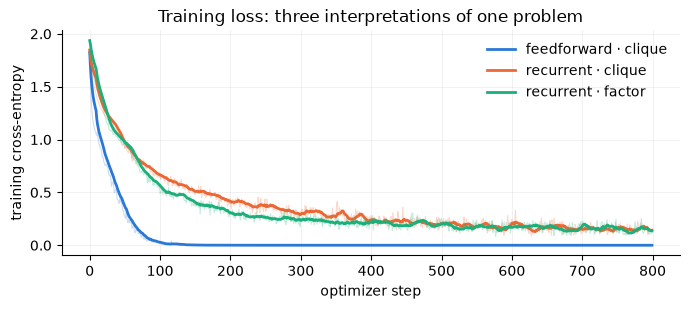

In [21]:
# colourblind-safe categorical triple, in fixed slot order
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
RUNS = [(history_ff, BLUE, "feedforward · clique"),
        (history_rec, ORANGE, "recurrent · clique"),
        (history_fac, AQUA, "recurrent · factor")]


def smooth(values, window=10):
    """Rolling mean, same length as the input."""
    cumulative = [0.0]
    for value in values:
        cumulative.append(cumulative[-1] + value)
    return [(cumulative[i + 1] - cumulative[max(0, i + 1 - window)])
            / min(i + 1, window) for i in range(len(values))]


fig, ax = plt.subplots(figsize=(7, 3.2))
for history, colour, label in RUNS:
    ax.plot(history["loss"], color=colour, alpha=0.25, linewidth=0.8)
    ax.plot(smooth(history["loss"]), color=colour, linewidth=2, label=label)
ax.set_xlabel("optimizer step")
ax.set_ylabel("training cross-entropy")
ax.set_title("Training loss: three interpretations of one problem")
ax.grid(alpha=0.25, linewidth=0.5)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

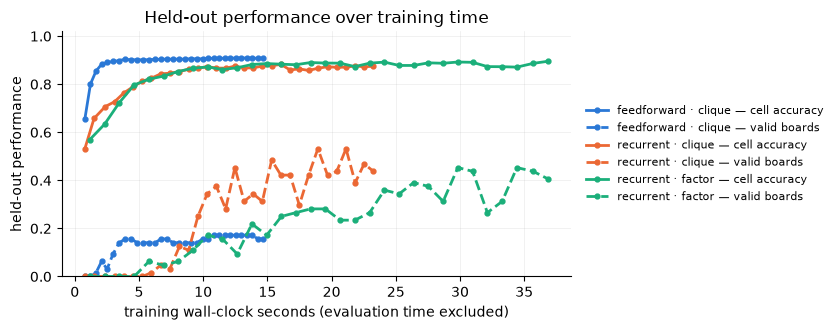

In [22]:
fig, ax = plt.subplots(figsize=(8.5, 3.4))
for history, colour, label in RUNS:
    ax.plot(history["seconds"], history["cell"], color=colour, linewidth=2,
            marker="o", markersize=3.5, label=f"{label} — cell accuracy")
    ax.plot(history["seconds"], history["valid"], color=colour, linewidth=2,
            linestyle="--", marker="o", markersize=3.5,
            label=f"{label} — valid boards")
ax.set_xlabel("training wall-clock seconds (evaluation time excluded)")
ax.set_ylabel("held-out performance")
ax.set_ylim(0, 1.02)
ax.set_title("Held-out performance over training time")
ax.grid(alpha=0.25, linewidth=0.5)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc="center left",
          bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
plt.show()

## 7. Where this goes: the 9×9 study

Nothing in this notebook is specific to small grids, and the 9×9 study under
`docs/neural` is precisely this formalism at scale:

* **`experiments/skeleton.py`** is Section 2 grown up: the roles are
  `message`, `peer`, `state`, `clue`, `answer`, and there are two skeletons —
  `factor_graph` (81 cell shells wired to 27 row/column/block *unit* shells,
  the 9×9 version of Section 5.1) and `clique` (81 cells with all 972
  pairwise peer wires).
* **`experiments/maps.py`** is Section 3 grown up: `interpret` is the very
  function we re-derived, and `factor_functor` / `clique_functor` are the
  functors.  Models A and C interpret the *same* `factor_graph` skeleton and
  differ only on the `answer` role: `Dim(0)` for A — erased, exactly like our
  feedforward functor erased the loops — and `Dim(48)` for C.
* **`experiments/models.py`** is Section 5 grown up: three solvers —
  **A (GoI)** on the factor graph, **B (RRN)**, Palm et al.'s recurrent
  relational network, on the clique with full hidden states on the wires, and
  **C (TRM-inspired)**, which changes *neither* the skeleton nor the functor
  but the **evaluation strategy**: because rounds compose,
  $F^{a+b} = F^b \circ F^a$, its outer loop runs message passing in
  resumable segments and backpropagates only through the last one.

At that scale and budget the two topologies we just raced change places:
model A reaches 0.887 test boards against model B's 0.720 (see the result
headers of `train_a_goi.py` and `train_b_rrn.py`) — the hyperedge box that
lost at 6×6/800 steps wins at 9×9/50k puzzles, run deep enough to pay its
two-rounds-per-hop toll.

The punchline of the whole construction: **architecture search is functor
search**.  Swap a module, widen a role, erase a loop, stretch a block — the
skeleton family, the training loop and the data pipeline all stay put.